In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Define the path to where you saved the files in your Drive
# (If you named your folder differently, change 'Pricing_Project_Data' to match)
path = '/content/drive/MyDrive/Pricing_Project_Data/'

# Load the datasets
orders_df = pd.read_csv(path + 'olist_order_items_dataset.csv')
products_df = pd.read_csv(path + 'olist_products_dataset.csv')

# Merge them
df_train = pd.merge(orders_df, products_df, on='product_id', how='inner')

print("Data loaded and merged successfully!")


Data loaded and merged successfully!


In [ ]:
import pandas as pd
import numpy as np

# 1. Format the Timestamps (we need the order_purchase_timestamp from the orders dataset)
# If your merged df_train doesn't have order_purchase_timestamp, you may need to also merge 'olist_orders_dataset.csv'
# Let's assume you have it or 'shipping_limit_date' which acts as a proxy for time
if 'shipping_limit_date' in df_train.columns:
    df_train['shipping_limit_date'] = pd.to_datetime(df_train['shipping_limit_date'])
    time_col = 'shipping_limit_date'
else:
    print("Warning: We need a date column to extract temporal features!")

# 2. Extract Temporal Features
df_train['day_of_week'] = df_train[time_col].dt.dayofweek
df_train['is_weekend'] = df_train['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df_train['month'] = df_train[time_col].dt.month

# 3. Engineer the "Competitor/Market" Signals
# The Olist dataset uses Portuguese categories by default (e.g., 'cama_mesa_banho')
# We calculate the mean price per category
category_avg_price = df_train.groupby('product_category_name')['price'].transform('mean')
df_train['category_avg_price'] = category_avg_price

# Calculate the Elasticity Ratio (How much more/less expensive is this item?)
df_train['price_ratio'] = df_train['price'] / df_train['category_avg_price']

# 4. Engineer the "Friction" Signal (Total Cost)
df_train['total_cost'] = df_train['price'] + df_train['freight_value']

# 5. Clean up missing values
df_train = df_train.dropna(subset=['price', 'freight_value', 'product_category_name'])

# 6. Verify the Final Dataset
ml_features = ['price', 'freight_value', 'total_cost', 'category_avg_price',
               'price_ratio', 'day_of_week', 'is_weekend', 'month']

print("--- Feature Engineering Complete! ---")
print(f"Total clean rows ready for training: {len(df_train)}")
print("\nFirst 5 rows of our ML features:")
print(df_train[ml_features].head())

--- Feature Engineering Complete! ---
Total clean rows ready for training: 111047

First 5 rows of our ML features:
    price  freight_value  total_cost  category_avg_price  price_ratio  \
0   58.90          13.29       72.19          167.357969     0.351940   
1  239.90          19.93      259.83          110.074684     2.179429   
2  199.00          17.87      216.87           87.564494     2.272611   
3   12.99          12.79       25.78          116.737312     0.111275   
4  199.90          18.14      218.04          111.630196     1.790734   

   day_of_week  is_weekend  month  
0            1           0      9  
1            2           0      5  
2            3           0      1  
3            2           0      8  
4            0           0      2  


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. PREP THE DATA FOR DEMAND PREDICTION ---
# Let's aggregate daily demand per category.
# How many items of a category were sold on a specific day at a specific average price?
daily_demand = df_train.groupby(['product_category_name', df_train[time_col].dt.date]).agg(
    daily_sales_volume=('price', 'count'), # This is our Target variable (Demand)
    avg_daily_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean'),
    category_avg_price=('category_avg_price', 'first'),
    is_weekend=('is_weekend', 'first'),
    month=('month', 'first')
).reset_index()

# Recalculate the daily price ratio based on the daily average
daily_demand['price_ratio'] = daily_demand['avg_daily_price'] / daily_demand['category_avg_price']

# Drop any NaN values that resulted from aggregation
daily_demand = daily_demand.dropna()

# Define our inputs (X) and our target output (y)
X = daily_demand[['avg_daily_price', 'avg_freight', 'category_avg_price', 'price_ratio', 'is_weekend', 'month']]
y = daily_demand['daily_sales_volume']

# Split into Training (80%) and Validation (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. NORMALIZE THE DATA ---
# Neural networks hate large unscaled numbers. We must scale X to have mean=0, variance=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. BUILD THE NEURAL NETWORK ---
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2), # Prevent overfitting
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1) # Linear output for regression (predicting volume)
])

# Compile the model using Adam optimizer and Mean Squared Error for regression
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='mse',
              metrics=['mae']) # Mean Absolute Error is easier to interpret

# --- 4. TRAIN THE MODEL ---
print("Starting training...")
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=30,          # How many times to loop through the data
    batch_size=32,      # How many rows to process at once
    verbose=1           # Print progress bar
)
print("Training Complete!")

Starting training...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 89.2774 - mae: 5.6964 - val_loss: 68.6083 - val_mae: 4.7298
Epoch 2/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 81.7314 - mae: 5.3676 - val_loss: 75.1107 - val_mae: 4.6502
Epoch 3/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 80.5046 - mae: 5.3127 - val_loss: 66.5309 - val_mae: 4.7316
Epoch 4/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 78.4865 - mae: 5.2484 - val_loss: 66.3456 - val_mae: 4.7146
Epoch 5/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 77.6028 - mae: 5.2458 - val_loss: 66.3868 - val_mae: 5.1423
Epoch 6/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 77.9532 - mae: 5.2801 - val_loss: 66.3102 - val_mae: 4.6782
Epoch 7/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 76.8365 - mae: 5.2325 - val_loss: 64.5950 - val_mae: 5.0563
Epoch 8/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 76.3450 - mae: 5.2486 - val_loss: 64.6896 - val_mae: 4.7047
Epoch 9/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Running Price Optimization Engine...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

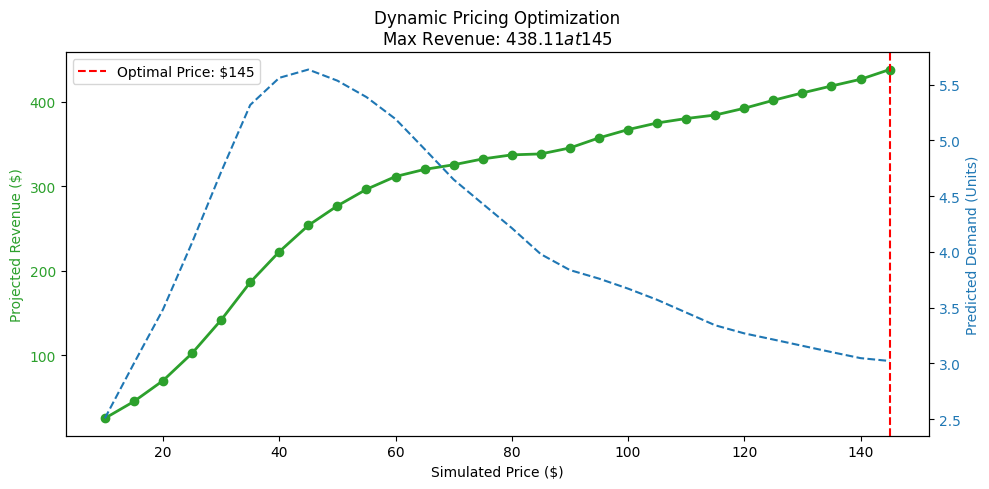

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def optimize_price(category_avg_price, avg_freight, is_weekend, month, price_min=10, price_max=150):
    """
    Simulates different prices to find the optimal price point that maximizes revenue.
    """
    test_prices = np.arange(price_min, price_max, 5) # Test prices in increments of 5
    projected_revenues = []
    predicted_demands = []

    for price in test_prices:
        # Calculate the dynamic price ratio for this specific test price
        simulated_ratio = price / category_avg_price

        # Create the input array exactly as the model expects it
        # Features: ['avg_daily_price', 'avg_freight', 'category_avg_price', 'price_ratio', 'is_weekend', 'month']
        input_data = np.array([[price, avg_freight, category_avg_price, simulated_ratio, is_weekend, month]])

        # Normalize the input using the scaler we fit earlier
        input_scaled = scaler.transform(input_data)

        # Ask the Neural Network to predict demand at this price
        pred_demand = model.predict(input_scaled, verbose=0)[0][0]

        # Neural networks can sometimes predict negative demand if pushed too far outside normal bounds
        pred_demand = max(0, pred_demand)

        # Calculate Projected Revenue
        revenue = price * pred_demand

        predicted_demands.append(pred_demand)
        projected_revenues.append(revenue)

    # Find the price that resulted in the highest revenue
    optimal_index = np.argmax(projected_revenues)
    optimal_price = test_prices[optimal_index]
    max_revenue = projected_revenues[optimal_index]

    # --- Visualization ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Revenue (Green Line)
    color = 'tab:green'
    ax1.set_xlabel('Simulated Price ($)')
    ax1.set_ylabel('Projected Revenue ($)', color=color)
    ax1.plot(test_prices, projected_revenues, color=color, marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.axvline(x=optimal_price, color='red', linestyle='--', label=f'Optimal Price: ${optimal_price}')
    ax1.legend(loc='upper left')

    # Plot Demand on a secondary Y-axis (Blue Dashed Line)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Predicted Demand (Units)', color=color)
    ax2.plot(test_prices, predicted_demands, color=color, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Dynamic Pricing Optimization\nMax Revenue: ${max_revenue:.2f} at ${optimal_price}')
    fig.tight_layout()
    plt.show()

    return optimal_price, max_revenue

# Let's test it!
# Imagine an item where the category average is $50, freight is $15, on a weekday (0) in November (11)
print("Running Price Optimization Engine...")
optimal_p, max_rev = optimize_price(category_avg_price=50.0, avg_freight=15.0, is_weekend=0, month=11)